## Name: Tasrif Nur Himel
### ID: 221-35-1078
### Course: DS424	- Machine Learning Driven Data Analysis II and Communicating Data Insights Lab (DS Major)
### Section: B1

### Install Library

In [2]:
!pip install -q transformers datasets seaborn

### Import Library

In [3]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

from sklearn.metrics import classification_report, accuracy_score

import pandas as pd
import seaborn as sns


### Load Dataset and do some simple EDA

In [4]:
SEED = 42
rng = np.random.default_rng(SEED)

imdb = load_dataset("imdb")

N_TRAIN, N_TEST = 10_000, 2_000
train_full, test_full = imdb["train"], imdb["test"]

train_idx = rng.choice(len(train_full), size=N_TRAIN, replace=False)
test_idx  = rng.choice(len(test_full),  size=N_TEST,  replace=False)

train_data = train_full.select(sorted(train_idx.tolist()))
test_data  = test_full.select(sorted(test_idx.tolist()))

print(f"Train samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

ex_text = train_data[0]["text"]
ex_label = train_data[0]["label"]
print("\nExample review:", (ex_text[:100] + "...") if len(ex_text) > 100 else ex_text)
print(f"Label: {ex_label} ({'Positive' if ex_label == 1 else 'Negative'})")

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train samples: 10000
Test samples: 2000

Example review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
Label: 0 (Negative)


###  Quick, necessary visualizations

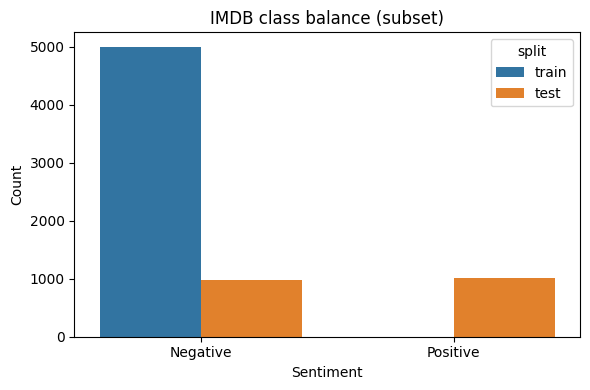

In [5]:
def to_frame(ds, split_name, max_rows=5000):
    take_n = min(max_rows, len(ds))
    subset = ds.select(range(take_n))
    df = pd.DataFrame({"text": subset["text"], "label": subset["label"]})
    df["split"] = split_name
    df["label_name"] = df["label"].map({0: "Negative", 1: "Positive"})
    df["word_len"] = df["text"].str.split().map(len)
    df["char_len"] = df["text"].str.len()
    return df

df_tr = to_frame(train_data, "train")
df_te = to_frame(test_data,  "test")
df_all = pd.concat([df_tr, df_te], ignore_index=True)

plt.figure(figsize=(6,4))
sns.countplot(data=df_all, x="label_name", hue="split")
plt.title("IMDB class balance (subset)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
df_train = pd.DataFrame({"text": train_data["text"], "label": train_data["label"]})
df_test  = pd.DataFrame({"text": test_data["text"],  "label": test_data["label"]})

In [7]:
df_train

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,Whoever wrote the screenplay for this movie ob...,0
2,I can't believe that those praising this movie...,0
3,Never cast models and Playboy bunnies in your ...,0
4,"Today I found ""They All Laughed"" on VHS on sal...",0
...,...,...
9995,"Very smart, sometimes shocking, I just love it...",1
9996,A hit at the time but now better categorised a...,1
9997,This film and it's sequel Barry Mckenzie holds...,1
9998,'The Adventures Of Barry McKenzie' started lif...,1


### model Load and Tokenizer setup

In [8]:
MODEL_ID = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=2,
    from_pt=True
)

trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_variables]))
non_trainable_params = int(np.sum([np.prod(v.shape) for v in model.non_trainable_variables]))

print(f"Loaded: {MODEL_ID}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSeq

Loaded: distilbert-base-uncased
Trainable params: 66,955,010
Non-trainable params: 0


### Tokenization / preprocessing

In [9]:
MAX_LEN = 256

def tokenize_batch(batch):
    encoded = tokenizer(
        batch["text"],
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
    )
    encoded["labels"] = batch["label"]
    return encoded

train_encoded = train_data.map(
    tokenize_batch,
    batched=True,
    remove_columns=[c for c in train_data.column_names if c not in ("text", "label")]
)
test_encoded = test_data.map(
    tokenize_batch,
    batched=True,
    remove_columns=[c for c in test_data.column_names if c not in ("text", "label")]
)

print("Features after tokenization (train):", train_encoded.features)
print("Example tokenized keys:", list(train_encoded[0].keys()))
print("Sample input_ids length:", len(train_encoded[0]["input_ids"]))
print("Label example:", train_encoded[0]["labels"])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Features after tokenization (train): {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos']), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': Value('int64')}
Example tokenized keys: ['text', 'label', 'input_ids', 'attention_mask', 'labels']
Sample input_ids length: 256
Label example: 0


### Convert tokenized Dataset to Tensorflow Dataset

In [10]:
def to_tfds(encoded_ds, batch_size=16, training=True, label_col="labels"):
    ds = encoded_ds.to_tf_dataset(
        columns=["input_ids", "attention_mask"],
        label_cols=[label_col],
        shuffle=training,
        batch_size=batch_size
    )
    return ds.cache().prefetch(tf.data.AUTOTUNE)

train_tf = to_tfds(train_encoded, batch_size=16, training=True,  label_col="labels")
test_tf  = to_tfds(test_encoded,  batch_size=16, training=False, label_col="labels")

for batch in train_tf.take(1):
    x, y = batch
    print({k: v.shape for k, v in x.items()}, "labels:", y.shape, y.dtype)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


{'input_ids': TensorShape([16, 256]), 'attention_mask': TensorShape([16, 256])} labels: (16,) <dtype: 'int64'>


### Compile model for training

In [11]:
learning_rate = 2e-5

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_imdb_distilbert.keras",
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

print("Model compiled. Ready to train.")

Model compiled. Ready to train.


### Training

(it's take too much time that's why i only run one epoch for better result you need to use torch gpu and at least 100 epoch)

In [13]:
import time

EPOCHS = 1

start = time.time()
history = model.fit(
    train_tf,
    validation_data=test_tf,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - start
print(f"\nTraining finished in {train_time/60:.2f} min")

625/625 [==============================] - 18628s 30s/step - loss: 0.3424 - accuracy: 0.8462 - val_loss: 0.3960 - val_accuracy: 0.8395 - lr: 2.0000e-05

Training finished in 310.47 min


### Plot training curves

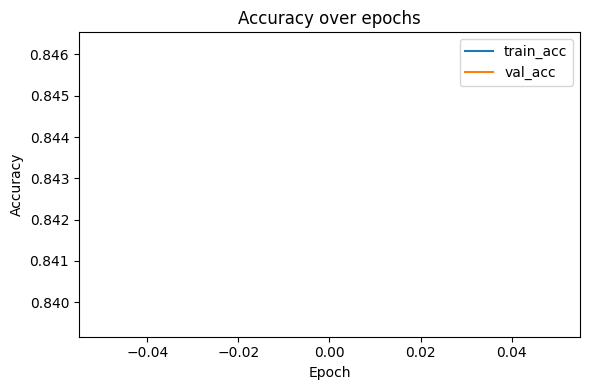

In [14]:
hist = history.history
plt.figure(figsize=(6,4))
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

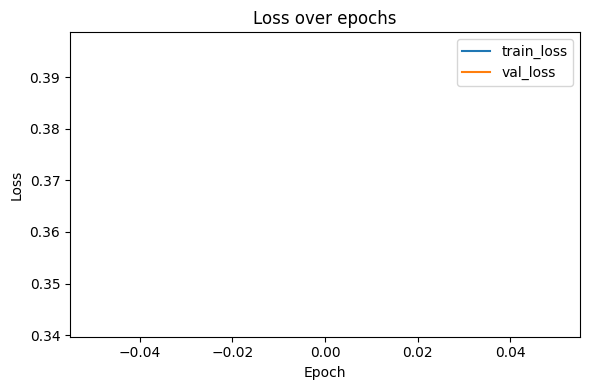

In [15]:
plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluation

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
y_true = []
for _, y in test_tf:
    y_true.append(y.numpy())
y_true = np.concatenate(y_true)

In [18]:
pred_out = model.predict(test_tf, verbose=0)
logits = pred_out.logits if hasattr(pred_out, "logits") else pred_out[0]
y_pred = np.argmax(logits, axis=-1)

In [19]:
test_acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))


Test Accuracy: 0.8395

              precision    recall  f1-score   support

    Negative       0.77      0.97      0.86       980
    Positive       0.96      0.71      0.82      1020

    accuracy                           0.84      2000
   macro avg       0.86      0.84      0.84      2000
weighted avg       0.87      0.84      0.84      2000



In [20]:
### Confuson Matrix

<Figure size 400x400 with 0 Axes>

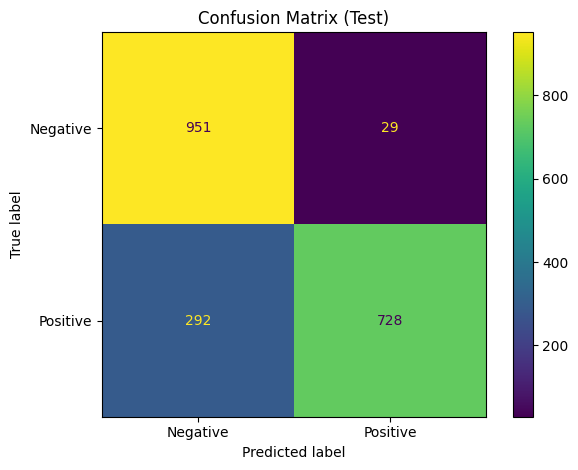

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
plt.figure(figsize=(4,4))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.show()


In [22]:
user_review = input("Enter a movie review: ")

enc = tokenizer(
    user_review,
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="tf"
)

logits = model(**enc).logits
pred_id = int(tf.argmax(logits, axis=-1).numpy()[0])

print("Predicted Sentiment:", "Positive" if pred_id == 1 else "Negative")

Enter a movie review: This is a Bad Movie


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Predicted Sentiment: Negative


In [23]:
user_review = input("Enter a movie review: ")

enc = tokenizer(
    user_review,
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="tf"
)

logits = model(**enc).logits
pred_id = int(tf.argmax(logits, axis=-1).numpy()[0])

print("Predicted Sentiment:", "Positive" if pred_id == 1 else "Negative")

Enter a movie review: This is a very good and informative mmoovie
Predicted Sentiment: Positive
